# Notebook 01: Data Loading, Target Creation, Merge, and Initial EDA

This notebook:
1. Loads Banner and Moodle.
2. Checks the data.
3. Creates the combined academic risk target.
4. Transforms the Banner key to match Moodle.
5. Keeps only matched students using an inner join.
6. Performs minimal EDA.
7. Saves the private merged dataset.

Preprocessing and modelling will be completed in later notebooks.


## 1. Import libraries


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Define folders, files, and column names


In [2]:
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"

BANNER_FILE = RAW_DATA_DIR / "banner.csv"
MOODLE_FILE = RAW_DATA_DIR / "moodle.csv"

BANNER_STUDENT_KEY = "student_key"
MOODLE_STUDENT_KEY = "student_key"
SEMESTER_COLUMN = "semester_code"

GPA_SOURCE = "end_term_gpa_range"
REGISTERED_CREDITS = "registered_credits"
EARNED_CREDITS = "earned_credits_this_semester"

TARGET = "academic_risk_label"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Banner file:", BANNER_FILE)
print("Moodle file:", MOODLE_FILE)


Project directory: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks
Banner file: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\data\raw\banner.csv
Moodle file: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\data\raw\moodle.csv


## 3. Load Banner and Moodle


In [3]:
def load_data(file_path):
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    if file_path.suffix.lower() == ".csv":
        return pd.read_csv(file_path)

    if file_path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(file_path)

    raise ValueError(f"Unsupported file type: {file_path.suffix}")


banner = load_data(BANNER_FILE)
moodle = load_data(MOODLE_FILE)

print("Banner shape:", banner.shape)
print("Moodle shape:", moodle.shape)


Banner shape: (3916, 24)
Moodle shape: (3770, 12)


## 4. Standardise column names


In [4]:
banner.columns = (
    banner.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

moodle.columns = (
    moodle.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("Banner columns:")
print(banner.columns.tolist())

print("\nMoodle columns:")
print(moodle.columns.tolist())


Banner columns:
['student_key', 'semester_code', 'programme_or_school', 'year_level', 'gender', 'registered_course_count', 'registered_credits', 'repeated_course_count_current', 'previous_term_gpa', 'previous_term_gpa_range', 'previous_cgpa', 'previous_cgpa_range', 'end_term_gpa', 'end_term_gpa_range', 'end_cgpa', 'end_cgpa_range', 'earned_credits_this_semester', 'credits_earned_ratio', 'previous_failed_course_count', 'previous_withdrawn_course_count', 'previous_repeated_course_count', 'previous_academic_standing', 'attendance_rate', 'absence_count']

Moodle columns:
['student_key', 'semester_code', 'enrolled_course_count', 'accessed_course_count', 'course_access_rate', 'total_course_event_clicks', 'active_days', 'active_days_rate', 'zero_activity_days', 'largest_inactivity_days', 'learning_material_events', 'assessment_interaction_events']


## 5. Initial data checks


In [5]:
print("Banner exact duplicate rows:", banner.duplicated().sum())
print("Moodle exact duplicate rows:", moodle.duplicated().sum())

print("\nTop Banner missing values:")
display(
    banner.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
    .head(15)
)

print("\nTop Moodle missing values:")
display(
    moodle.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
    .head(15)
)


Banner exact duplicate rows: 0
Moodle exact duplicate rows: 0

Top Banner missing values:


,missing_count
previous_term_gpa_range,323
previous_term_gpa,323
previous_cgpa_range,299
previous_cgpa,299
previous_academic_standing,299
end_term_gpa_range,41
end_term_gpa,41
earned_credits_this_semester,41
end_cgpa_range,2
end_cgpa,2



Top Moodle missing values:


,missing_count
student_key,0
semester_code,0
enrolled_course_count,0
accessed_course_count,0
course_access_rate,0
total_course_event_clicks,0
active_days,0
active_days_rate,0
zero_activity_days,0
largest_inactivity_days,0


## 6. Validate required target and key columns


In [6]:
required_banner_columns = [
    GPA_SOURCE,
    REGISTERED_CREDITS,
    EARNED_CREDITS,
    BANNER_STUDENT_KEY,
]

missing_banner_columns = [
    column for column in required_banner_columns
    if column not in banner.columns
]

if missing_banner_columns:
    raise KeyError(
        f"Missing required Banner columns: {missing_banner_columns}"
    )

if MOODLE_STUDENT_KEY not in moodle.columns:
    raise KeyError(
        f"Missing Moodle key column: {MOODLE_STUDENT_KEY}"
    )

print("All required target and key columns are available.")


All required target and key columns are available.


## 7. Create the combined academic risk target

A student is labelled as at risk when either:

- The end cumulative GPA band is below 2.25.
- The credit deficit is greater than 15 credits.

Target:
- `1` = At risk
- `0` = Not at risk
- Missing = Both target sources are missing


In [7]:
# =========================================================
# CREATE AND VALIDATE THE COMBINED TARGET
# =========================================================

import numpy as np
import pandas as pd

# Standardise Banner column names
banner.columns = (
    banner.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Confirm these names match your actual Banner columns

GPA_SOURCE = "end_term_gpa_range"
REGISTERED_CREDITS = "registered_credits"
EARNED_CREDITS = "earned_credits_this_semester"
TARGET = "academic_risk_label"

required_columns = [
    GPA_SOURCE,
    REGISTERED_CREDITS,
    EARNED_CREDITS,
]

missing_columns = [
    column
    for column in required_columns
    if column not in banner.columns
]

if missing_columns:
    raise KeyError(
        f"These columns are missing from Banner: {missing_columns}\n"
        f"Available columns are:\n{banner.columns.tolist()}"
    )

# Clean the GPA band values
banner[GPA_SOURCE] = (
    banner[GPA_SOURCE]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace(" ", "_", regex=False)
)

# Convert credit columns to numeric
banner[REGISTERED_CREDITS] = pd.to_numeric(
    banner[REGISTERED_CREDITS],
    errors="coerce",
)

banner[EARNED_CREDITS] = pd.to_numeric(
    banner[EARNED_CREDITS],
    errors="coerce",
)

# Define all valid GPA bands
at_risk_gpa_bins = {
    "0.00_TO_<1.00",
    "1.00_TO_<2.00",
    "2.00_TO_<2.25",
}

not_at_risk_gpa_bins = {
    "2.25_TO_<2.50",
    "2.50_TO_<3.00",
    "3.00_TO_4.00",
}

all_valid_gpa_bins = (
    at_risk_gpa_bins
    | not_at_risk_gpa_bins
)

# GPA rule
gpa_valid = banner[GPA_SOURCE].isin(
    all_valid_gpa_bins
)

gpa_flag = banner[GPA_SOURCE].isin(
    at_risk_gpa_bins
)

# Credit deficit rule
banner["credit_deficit"] = (
    banner[REGISTERED_CREDITS]
    - banner[EARNED_CREDITS]
)

credit_valid = (
    banner[REGISTERED_CREDITS].notna()
    & banner[EARNED_CREDITS].notna()
)

credit_flag = (
    credit_valid
    & (banner["credit_deficit"] > 15)
)

# Create target
any_source_valid = gpa_valid | credit_valid
combined_risk = gpa_flag | credit_flag

banner[TARGET] = pd.Series(
    pd.NA,
    index=banner.index,
    dtype="Int64",
)

# At risk when either rule is true
banner.loc[
    combined_risk,
    TARGET,
] = 1

# Not at risk when at least one source is valid
# and neither rule indicates risk
banner.loc[
    any_source_valid & ~combined_risk,
    TARGET,
] = 0

# Create a clear source description
banner["risk_source"] = "Missing target sources"

banner.loc[
    any_source_valid & ~combined_risk,
    "risk_source",
] = "Not at risk"

banner.loc[
    gpa_flag & ~credit_flag,
    "risk_source",
] = "GPA risk only"

banner.loc[
    ~gpa_flag & credit_flag,
    "risk_source",
] = "Credit deficit risk only"

banner.loc[
    gpa_flag & credit_flag,
    "risk_source",
] = "Both GPA and credit deficit"

# Display results before dropping missing targets
print("Observed GPA values:")
print(
    banner[GPA_SOURCE]
    .value_counts(dropna=False)
)

print("\nTarget before dropping missing records:")
print(
    banner[TARGET]
    .value_counts(dropna=False)
)

print("\nRisk source:")
print(
    banner["risk_source"]
    .value_counts(dropna=False)
)

# Drop records that still have no target
rows_before = len(banner)

banner = (
    banner
    .dropna(subset=[TARGET])
    .reset_index(drop=True)
)

banner[TARGET] = banner[TARGET].astype("Int64")

rows_after = len(banner)

print("\nRows before dropping missing targets:", rows_before)
print("Rows after dropping missing targets:", rows_after)
print("Rows removed:", rows_before - rows_after)

print("\nFinal target distribution:")
print(
    banner[TARGET]
    .value_counts(dropna=False)
)

# Final validation
assert banner[TARGET].isna().sum() == 0
assert set(banner[TARGET].unique()).issubset({0, 1})

print("\nTarget created successfully.")

Observed GPA values:
end_term_gpa_range
3.00_TO_4.00     1696
2.50_TO_<3.00     880
1.00_TO_<2.00     478
0.00_TO_<1.00     315
2.25_TO_<2.50     274
2.00_TO_<2.25     232
<NA>               41
Name: count, dtype: Int64

Target before dropping missing records:
academic_risk_label
0       2838
1       1037
<NA>      41
Name: count, dtype: Int64

Risk source:
risk_source
Not at risk                    2838
Both GPA and credit deficit     593
GPA risk only                   432
Missing target sources           41
Credit deficit risk only         12
Name: count, dtype: int64

Rows before dropping missing targets: 3916
Rows after dropping missing targets: 3875
Rows removed: 41

Final target distribution:
academic_risk_label
0    2838
1    1037
Name: count, dtype: Int64

Target created successfully.


In [8]:
print("GPA risk total:", int(gpa_flag.sum()))
print("Credit deficit risk total:", int(credit_flag.sum()))
print("Both GPA and credit risk:", int((gpa_flag & credit_flag).sum()))
print("GPA risk only:", int((gpa_flag & ~credit_flag).sum()))
print("Credit risk only:", int((~gpa_flag & credit_flag).sum()))

GPA risk total: 1025
Credit deficit risk total: 605
Both GPA and credit risk: 593
GPA risk only: 432
Credit risk only: 12


In [9]:
print("Mutually exclusive risk categories:")

display(
    banner["risk_source"]
    .value_counts(dropna=False)
    .rename_axis("risk_source")
    .to_frame("count")
)

print("\nTotal students meeting each rule:")

rule_summary = pd.DataFrame({
    "risk_rule": [
        "GPA below 2.25",
        "Credit deficit greater than 15",
        "Either rule",
    ],
    "student_count": [
        int(gpa_flag.sum()),
        int(credit_flag.sum()),
        int((gpa_flag | credit_flag).sum()),
    ],
})

display(rule_summary)

Mutually exclusive risk categories:


,count
risk_source,
Not at risk,2838
Both GPA and credit deficit,593
GPA risk only,432
Credit deficit risk only,12



Total students meeting each rule:


,risk_rule,student_count
0,GPA below 2.25,1025
1,Credit deficit greater than 15,605
2,Either rule,1037


In [10]:
risk_overlap = pd.crosstab(
    gpa_flag,
    credit_flag,
    rownames=["GPA risk"],
    colnames=["Credit deficit risk"],
    margins=True,
)

display(risk_overlap)

Credit deficit risk,False,True,All
GPA risk,,,
False,2879,12,2891
True,432,593,1025
All,3311,605,3916


## 8. Validate the target


In [11]:
print("Observed end CGPA bands:")
print(
    sorted(
        banner[GPA_SOURCE]
        .dropna()
        .unique()
        .tolist()
    )
)

print("\nCredit deficit summary:")
display(
    banner["credit_deficit"]
    .describe()
    .to_frame()
)

print(
    "Negative credit deficits:",
    int((banner["credit_deficit"] < 0).sum()),
)

print(
    "Missing target labels:",
    int(banner[TARGET].isna().sum()),
)


Observed end CGPA bands:
['0.00_TO_<1.00', '1.00_TO_<2.00', '2.00_TO_<2.25', '2.25_TO_<2.50', '2.50_TO_<3.00', '3.00_TO_4.00']

Credit deficit summary:


,credit_deficit
count,3875.000000
mean,9.140645
std,16.690093
min,0.000000
25%,0.000000
50%,0.000000
75%,15.000000
max,105.000000


Negative credit deficits: 0
Missing target labels: 0


In [15]:
banner.head(5)

,student_key,semester_code,programme_or_school,year_level,gender,registered_course_count,registered_credits,repeated_course_count_current,previous_term_gpa,previous_term_gpa_range,previous_cgpa,previous_cgpa_range,end_term_gpa,end_term_gpa_range,end_cgpa,end_cgpa_range,earned_credits_this_semester,credits_earned_ratio,previous_failed_course_count,previous_withdrawn_course_count,previous_repeated_course_count,previous_academic_standing,attendance_rate,absence_count,credit_deficit,academic_risk_label,risk_source,merge_student_key
0,6AA775B5799839105FF44759EA684C8F4C3128CDA70ADC...,202502,Bachelor of Business,1,Female,3,45,0,High,3.00 to 4.00,High,3.00 to 4.00,High,3.00_TO_4.00,High,3.00 to 4.00,45.0,1.0000,0,0,0,Good Standing,26.67,22,0.0,0,Not at risk,6AA775B5799839105FF44759EA684C8F4C3128CDA70ADC...
1,8CF53ABBF3DF243FD73E0CF98EDB2C87B9793D9FCDFDA9...,202502,Bachelor of Business,1,Female,5,60,0,Good,2.50 to <3.00,Good,2.50 to <3.00,Low,1.00_TO_<2.00,Near Threshold,2.25 to <2.50,30.0,0.7500,0,0,0,Good Standing,28.00,32,30.0,1,Both GPA and credit deficit,8CF53ABBF3DF243FD73E0CF98EDB2C87B9793D9FCDFDA9...
2,D51B7B16DD2041F3C7AA9608216ED0646F7DAC77B0D2BC...,202502,Bachelor of Business,1,Female,5,60,0,High,3.00 to 4.00,High,3.00 to 4.00,Good,2.50_TO_<3.00,Good,2.50 to <3.00,60.0,1.0000,0,0,0,Good Standing,50.00,27,0.0,0,Not at risk,D51B7B16DD2041F3C7AA9608216ED0646F7DAC77B0D2BC...
3,C5BFD4C2769BB0AEEB47F51A8EFBA84CF239C7B770C2E2...,202502,Bachelor of Business,1,Female,4,45,0,High,3.00 to 4.00,High,3.00 to 4.00,Probation Range,2.00_TO_<2.25,Good,2.50 to <3.00,30.0,1.1667,0,1,0,Good Standing,37.50,22,15.0,1,GPA risk only,C5BFD4C2769BB0AEEB47F51A8EFBA84CF239C7B770C2E2...
4,BE3331949FCDB623110A8CD964A18A3B3899F03EC52B2C...,202502,Bachelor of Business,1,Female,5,50,0,Good,2.50 to <3.00,High,3.00 to 4.00,Low,1.00_TO_<2.00,Good,2.50 to <3.00,30.0,0.4884,2,0,0,Good Standing,24.00,29,20.0,1,Both GPA and credit deficit,BE3331949FCDB623110A8CD964A18A3B3899F03EC52B2C...


In [16]:
moodle.head(5)

,student_key,semester_code,enrolled_course_count,accessed_course_count,course_access_rate,total_course_event_clicks,active_days,active_days_rate,zero_activity_days,largest_inactivity_days,learning_material_events,assessment_interaction_events,merge_student_key
0,7148370806DA2AF956BAFCB249411152FCC1B40398FA62...,202502,2,2,1.0,484,13,0.3824,21,9,Moderate,Moderate,7148370806DA2AF956BAFCB249411152FCC1B40398FA62...
1,4C7ABF7C9513C090F6C269CA8789234A727519934373BA...,202502,3,3,1.0,188,6,0.1765,28,11,Very Low,Low,4C7ABF7C9513C090F6C269CA8789234A727519934373BA...
2,DD61472EBAD20E184B7E20C0C27F7BC4E6AC123D69758A...,202502,4,4,1.0,208,11,0.3235,23,10,Low,Very Low,DD61472EBAD20E184B7E20C0C27F7BC4E6AC123D69758A...
3,2CBF9A3A8239728E2C52613D77DF57516761C40E404603...,202502,3,3,1.0,490,21,0.6176,13,5,Good,Moderate,2CBF9A3A8239728E2C52613D77DF57516761C40E404603...
4,D879BC5AC8CC78FC8313BC3797E4057552712BEF98C791...,202502,2,2,1.0,83,6,0.1765,28,10,Moderate,Low,D879BC5AC8CC78FC8313BC3797E4057552712BEF98C791...


## 11. Inner join Banner and Moodle


In [17]:
# Clean student_key in both datasets
banner["student_key"] = (
    banner["student_key"]
    .astype("string")
    .str.strip()
    .str.upper()
)

moodle["student_key"] = (
    moodle["student_key"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Remove rows with missing student keys
banner_clean = banner.dropna(
    subset=["student_key"]
).copy()

moodle_clean = moodle.dropna(
    subset=["student_key"]
).copy()

# Check duplicate keys before merging
banner_duplicates = banner_clean["student_key"].duplicated().sum()
moodle_duplicates = moodle_clean["student_key"].duplicated().sum()

print("Banner duplicate student keys:", banner_duplicates)
print("Moodle duplicate student keys:", moodle_duplicates)

if banner_duplicates > 0 or moodle_duplicates > 0:
    raise ValueError(
        "Duplicate student_key values were found. "
        "Review duplicates before performing a one to one merge."
    )

# Check how many students exist in both datasets
banner_keys = set(banner_clean["student_key"])
moodle_keys = set(moodle_clean["student_key"])

matched_keys = banner_keys & moodle_keys

print("\nBanner students:", len(banner_keys))
print("Moodle students:", len(moodle_keys))
print("Students in both datasets:", len(matched_keys))
print("Banner only:", len(banner_keys - moodle_keys))
print("Moodle only:", len(moodle_keys - banner_keys))

# Inner join keeps only students who exist in both datasets
merged = banner_clean.merge(
    moodle_clean,
    on="student_key",
    how="inner",
    suffixes=("_banner", "_moodle"),
    validate="one_to_one",
)

print("\nMerge completed successfully.")
print("Merged rows:", len(merged))
print("Merged columns:", merged.shape[1])
print("Unique merged students:", merged["student_key"].nunique())

print("\nMerged target distribution:")
display(
    merged["academic_risk_label"]
    .value_counts(dropna=False)
    .rename_axis("academic_risk_label")
    .to_frame("count")
)

Banner duplicate student keys: 0
Moodle duplicate student keys: 0

Banner students: 3875
Moodle students: 3770
Students in both datasets: 3760
Banner only: 115
Moodle only: 10

Merge completed successfully.
Merged rows: 3760
Merged columns: 40
Unique merged students: 3760

Merged target distribution:


,count
academic_risk_label,
0,2827
1,933


## 12. Quality checks after merging


In [19]:
post_merge_checks = pd.DataFrame({
    "check": [
        "Merged rows",
        "Merged columns",
        "Unique matched students",
        "Duplicated student keys",
        "Missing target labels",
        "Exact duplicate rows",
    ],
    "value": [
        len(merged),
        merged.shape[1],
        merged["student_key"].nunique(),
        merged["student_key"].duplicated().sum(),
        merged[TARGET].isna().sum(),
        merged.duplicated().sum(),
    ],
})

display(post_merge_checks)

print("Top missing columns after merge:")
display(
    merged.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_percentage")
    .head(15)
)


,check,value
0,Merged rows,3760
1,Merged columns,40
2,Unique matched students,3760
3,Duplicated student keys,0
4,Missing target labels,0
5,Exact duplicate rows,0


Top missing columns after merge:


,missing_percentage
previous_term_gpa_range,8.058511
previous_term_gpa,8.058511
previous_cgpa_range,7.845745
previous_cgpa,7.845745
previous_academic_standing,7.819149
student_key,0.000000
programme_or_school,0.000000
semester_code_banner,0.000000
repeated_course_count_current,0.000000
registered_credits,0.000000


## 13. Minimal exploratory data analysis


,count
academic_risk_label,
Not at risk,2827
At risk,933


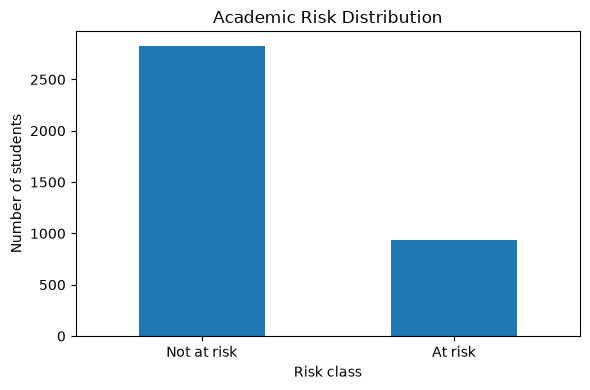

In [20]:
target_counts = (
    merged[TARGET]
    .map({
        0: "Not at risk",
        1: "At risk",
    })
    .value_counts()
)

display(target_counts.to_frame("count"))

target_counts.plot(
    kind="bar",
    figsize=(6, 4),
)

plt.title("Academic Risk Distribution")
plt.xlabel("Risk class")
plt.ylabel("Number of students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "target_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


,count
risk_source,
Not at risk,2827
Both GPA and credit deficit,531
GPA risk only,390
Credit deficit risk only,12


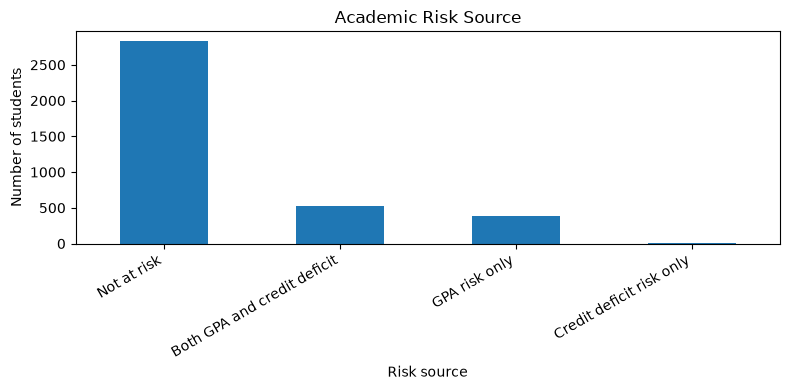

In [21]:
risk_source_counts = merged["risk_source"].value_counts()

display(risk_source_counts.to_frame("count"))

risk_source_counts.plot(
    kind="bar",
    figsize=(8, 4),
)

plt.title("Academic Risk Source")
plt.xlabel("Risk source")
plt.ylabel("Number of students")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "risk_source_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [22]:
numeric_columns = (
    merged
    .select_dtypes(include="number")
    .columns
    .tolist()
)

numeric_columns = [
    column
    for column in numeric_columns
    if column != TARGET
]

display(
    merged[numeric_columns]
    .describe()
    .T
)


,count,mean,std,min,25%,50%,75%,max
semester_code_banner,3760.0,202502.000000,0.000000,202502.0,202502.0000,202502.0000,202502.0000,202502.0000
year_level,3760.0,2.558777,1.105382,1.0,2.0000,3.0000,4.0000,4.0000
registered_course_count,3760.0,4.186968,1.185570,1.0,4.0000,4.0000,5.0000,9.0000
registered_credits,3760.0,58.618351,13.304678,10.0,45.0000,60.0000,60.0000,125.0000
earned_credits_this_semester,3760.0,50.115691,15.322851,0.0,45.0000,60.0000,60.0000,125.0000
credits_earned_ratio,3760.0,0.989317,0.282778,0.0,0.8889,1.0000,1.0000,2.8261
attendance_rate,3760.0,31.082827,18.254469,0.0,20.0000,30.0000,42.0000,100.0000
absence_count,3760.0,22.868085,10.831493,0.0,17.0000,25.0000,31.0000,45.0000
credit_deficit,3760.0,8.502660,16.069813,0.0,0.0000,0.0000,15.0000,105.0000
semester_code_moodle,3760.0,202502.000000,0.000000,202502.0,202502.0000,202502.0000,202502.0000,202502.0000


EDA features found: ['attendance_rate', 'absence_count', 'course_access_rate', 'active_days_rate', 'learning_material_events', 'assessment_interaction_events', 'credit_deficit']


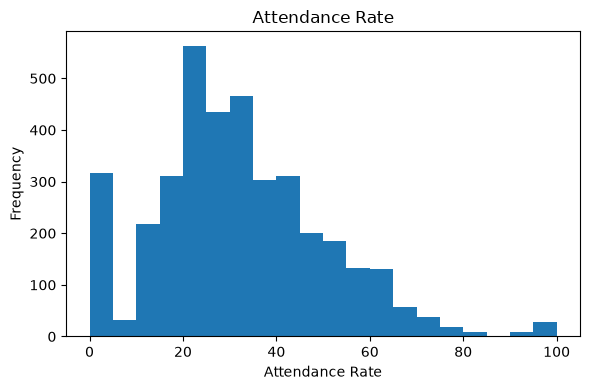

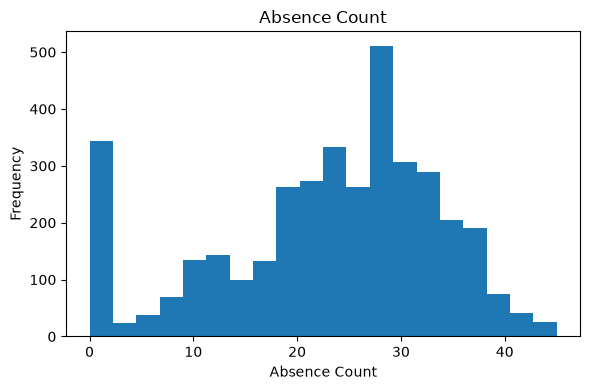

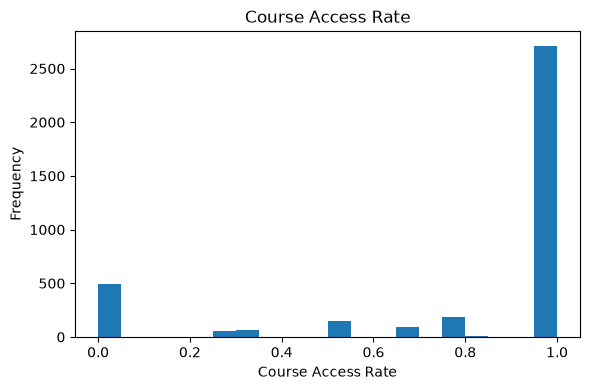

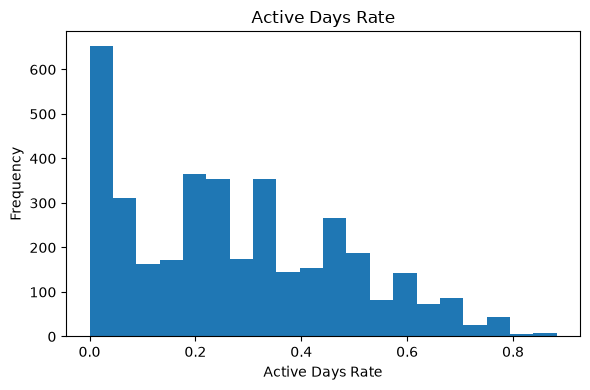

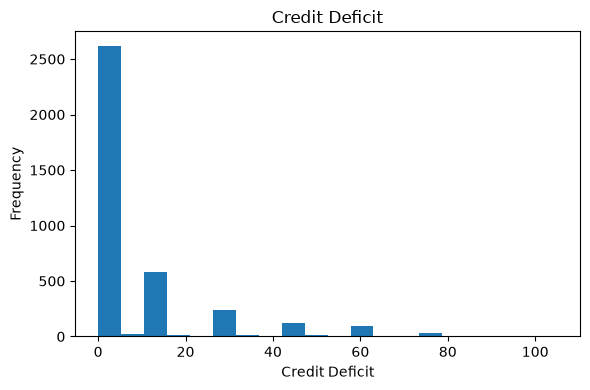

In [23]:
eda_features = [
    "attendance_rate",
    "absence_count",
    "course_access_rate",
    "active_days_rate",
    "total_moodle_course_events",
    "learning_material_events",
    "assessment_interaction_events",
    "credit_deficit",
]

eda_features = [
    column
    for column in eda_features
    if column in merged.columns
]

print("EDA features found:", eda_features)

for column in eda_features:
    values = pd.to_numeric(
        merged[column],
        errors="coerce",
    ).dropna()

    if values.empty:
        continue

    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=20)
    plt.title(
        column.replace("_", " ").title()
    )
    plt.xlabel(
        column.replace("_", " ").title()
    )
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"{column}_distribution.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


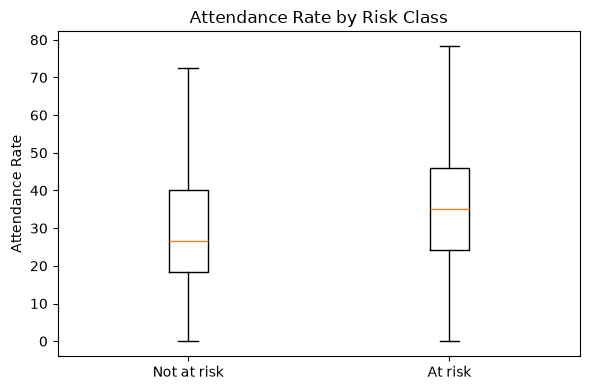

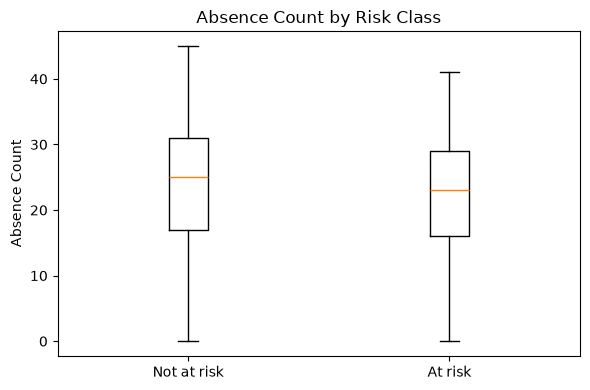

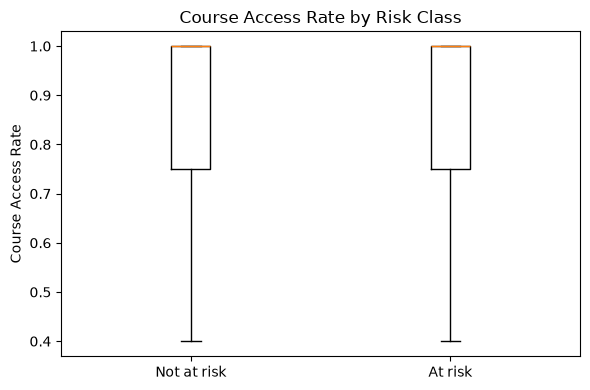

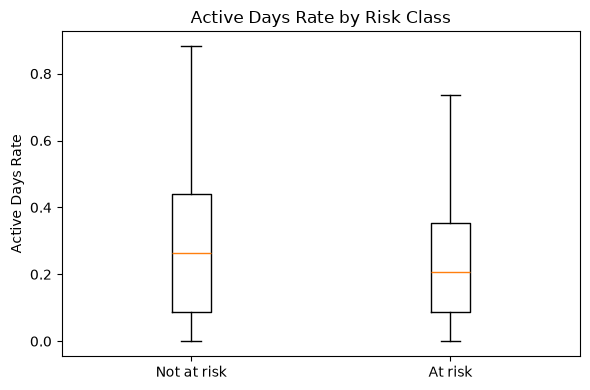

In [25]:
comparison_features = [
    column
    for column in [
        "attendance_rate",
        "absence_count",
        "course_access_rate",
        "active_days_rate",
        "total_moodle_course_events",
    ]
    if column in merged.columns
]

for column in comparison_features:
    comparison_data = merged[
        [TARGET, column]
    ].copy()

    comparison_data[column] = pd.to_numeric(
        comparison_data[column],
        errors="coerce",
    )

    comparison_data = comparison_data.dropna()

    not_at_risk = comparison_data.loc[
        comparison_data[TARGET] == 0,
        column,
    ]

    at_risk = comparison_data.loc[
        comparison_data[TARGET] == 1,
        column,
    ]

    if not_at_risk.empty or at_risk.empty:
        continue

    plt.figure(figsize=(6, 4))
    plt.boxplot(
        [not_at_risk, at_risk],
        showfliers=False,
    )
    plt.xticks([1, 2], ["Not at risk", "At risk"])
    plt.title(
        f"{column.replace('_', ' ').title()} by Risk Class"
    )
    plt.ylabel(
        column.replace("_", " ").title()
    )
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"{column}_by_risk.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


In [27]:
target_summary = (
    merged["academic_risk_label"]
    .value_counts()
    .sort_index()
    .rename_axis("academic_risk_label")
    .to_frame("count")
)

target_summary["risk_class"] = [
    "Not at risk",
    "At risk",
]

target_summary["percentage"] = (
    target_summary["count"]
    / target_summary["count"].sum()
    * 100
).round(2)

target_summary = target_summary[
    ["risk_class", "count", "percentage"]
]

display(target_summary)

,risk_class,count,percentage
academic_risk_label,,,
0,Not at risk,2827,75.19
1,At risk,933,24.81


In [28]:
final_quality_checks = pd.DataFrame({
    "check": [
        "Total merged records",
        "Unique students",
        "Duplicate student keys",
        "Missing target values",
        "Exact duplicate rows",
    ],
    "value": [
        len(merged),
        merged["student_key"].nunique(),
        merged["student_key"].duplicated().sum(),
        merged["academic_risk_label"].isna().sum(),
        merged.duplicated().sum(),
    ],
})

display(final_quality_checks)

,check,value
0,Total merged records,3760
1,Unique students,3760
2,Duplicate student keys,0
3,Missing target values,0
4,Exact duplicate rows,0


In [29]:
missing_summary = pd.DataFrame({
    "column": merged.columns,
    "missing_count": merged.isna().sum().values,
    "missing_percentage": (
        merged.isna().mean().values * 100
    ).round(2),
})

missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_percentage",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(missing_summary)

,column,missing_count,missing_percentage
0,previous_term_gpa,303,8.06
1,previous_term_gpa_range,303,8.06
2,previous_cgpa,295,7.85
3,previous_cgpa_range,295,7.85
4,previous_academic_standing,294,7.82


In [34]:
# Keep only available early features
early_features = [
    "attendance_rate",
    "absence_count",
    "course_access_rate",
    "total_moodle_course_events",
    "total_course_event_clicks",
    "active_days",
    "active_days_rate",
    "zero_activity_days",
    "largest_inactivity_days",
    "learning_material_events",
    "assessment_interaction_events",
]

early_features = [
    column
    for column in early_features
    if column in merged.columns
]

# Create a temporary copy for EDA
eda_summary_data = merged[
    ["academic_risk_label"] + early_features
].copy()

# Convert feature columns to numeric
for column in early_features:
    eda_summary_data[column] = (
        eda_summary_data[column]
        .astype("string")
        .str.strip()
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
    )

    eda_summary_data[column] = pd.to_numeric(
        eda_summary_data[column],
        errors="coerce",
    )

# Calculate mean values by risk class
feature_summary_by_risk = (
    eda_summary_data
    .groupby("academic_risk_label")[early_features]
    .mean()
    .T
)

feature_summary_by_risk = feature_summary_by_risk.rename(
    columns={
        0: "not_at_risk_mean",
        1: "at_risk_mean",
    }
)

feature_summary_by_risk["difference"] = (
    feature_summary_by_risk["at_risk_mean"]
    - feature_summary_by_risk["not_at_risk_mean"]
)

display(feature_summary_by_risk.round(3))

academic_risk_label,not_at_risk_mean,at_risk_mean,difference
attendance_rate,29.527,35.798,6.272
absence_count,23.331,21.464,-1.867
course_access_rate,0.802,0.816,0.014
total_course_event_clicks,295.918,213.596,-82.322
active_days,12.935,10.267,-2.668
active_days_rate,0.29,0.232,-0.058
zero_activity_days,24.136,26.103,1.967
largest_inactivity_days,13.935,14.823,0.888
learning_material_events,<NA>,<NA>,<NA>
assessment_interaction_events,<NA>,<NA>,<NA>


In [36]:
display(
    eda_summary_data[early_features]
    .describe()
    .T[["min", "max", "mean"]]
)

,min,max,mean
attendance_rate,0.0,100.0,31.082827
absence_count,0.0,45.0,22.868085
course_access_rate,0.0,1.0,0.805887
total_course_event_clicks,0.0,2964.0,275.490691
active_days,4.0,30.0,12.275036
active_days_rate,0.0,0.8824,0.275757
zero_activity_days,4.0,34.0,24.624202
largest_inactivity_days,5.0,34.0,14.155319
learning_material_events,<NA>,<NA>,<NA>
assessment_interaction_events,<NA>,<NA>,<NA>


## 14. Save the merged private dataset

The following columns must not be used as predictors later because they create or reveal the target:

- `end_cgpa_band`
- `earned_credits_this_semester`
- `credit_deficit`
- `risk_source`

`registered_credits` may remain a predictor because it is known at the start of the semester.


In [37]:
output_file = (
    PROCESSED_DATA_DIR
    / "merged_banner_moodle_with_target.pkl"
)

merged.to_pickle(output_file)

print("Private merged dataset saved to:")
print(output_file)


Private merged dataset saved to:
c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\data\processed\merged_banner_moodle_with_target.pkl


In [38]:
print("Merged shape:", merged.shape)

print("\nTarget distribution:")
display(
    merged["academic_risk_label"]
    .value_counts(dropna=False)
    .rename_axis("academic_risk_label")
    .to_frame("count")
)

print("\nMerged columns:")
print(merged.columns.tolist())

Merged shape: (3760, 40)

Target distribution:


,count
academic_risk_label,
0,2827
1,933



Merged columns:
['student_key', 'semester_code_banner', 'programme_or_school', 'year_level', 'gender', 'registered_course_count', 'registered_credits', 'repeated_course_count_current', 'previous_term_gpa', 'previous_term_gpa_range', 'previous_cgpa', 'previous_cgpa_range', 'end_term_gpa', 'end_term_gpa_range', 'end_cgpa', 'end_cgpa_range', 'earned_credits_this_semester', 'credits_earned_ratio', 'previous_failed_course_count', 'previous_withdrawn_course_count', 'previous_repeated_course_count', 'previous_academic_standing', 'attendance_rate', 'absence_count', 'credit_deficit', 'academic_risk_label', 'risk_source', 'merge_student_key_banner', 'semester_code_moodle', 'enrolled_course_count', 'accessed_course_count', 'course_access_rate', 'total_course_event_clicks', 'active_days', 'active_days_rate', 'zero_activity_days', 'largest_inactivity_days', 'learning_material_events', 'assessment_interaction_events', 'merge_student_key_moodle']


## Notebook 01 complete

Completed:
1. Loaded Banner and Moodle.
2. Checked missing values and duplicates.
3. Created the combined target.
4. Transformed and validated the merge key.
5. Kept only matched students.
6. Performed minimal EDA.
7. Saved the private merged dataset.

Notebook 02 will cover feature selection, leakage removal, missing value treatment, encoding, scaling, and train test splitting.
